In [1]:
import requests
import json
import os

# ------------------------------------------------------
# 1. ArcGIS REST API endpoint
# ------------------------------------------------------
url = "https://gis.dnr.wa.gov/site3/rest/services/Public_Boundaries/WADNR_PUBLIC_Cadastre_OpenData/FeatureServer/11/query"
params = {
    "where": "1=1",
    "outFields": "*",
    "outSR": "4326",    # WGS84 lat/lon
    "f": "json"
}

print("Downloading ArcGIS REST layer...")
resp = requests.get(url, params=params)
resp.raise_for_status()

arcgis_json = resp.json()
features = arcgis_json["features"]

print("Features downloaded:", len(features))

# ------------------------------------------------------
# 2. Convert ArcGIS polygons to GeoJSON polygons
# ------------------------------------------------------
geojson_features = []

for feat in features:
    attrs = feat.get("attributes", {})
    geom = feat.get("geometry", {})

    # ArcGIS returns rings for polygons
    rings = geom.get("rings", [])

    # Convert (x,y) pairs into GeoJSON format (lon, lat)
    polygons = []
    for ring in rings:
        polygons.append([[pt[0], pt[1]] for pt in ring])

    geojson_features.append({
        "type": "Feature",
        "properties": attrs,
        "geometry": {
            "type": "Polygon",
            "coordinates": polygons
        }
    })

# ------------------------------------------------------
# 3. GeoJSON FeatureCollection
# ------------------------------------------------------
geojson_data = {
    "type": "FeatureCollection",
    "features": geojson_features
}

# ------------------------------------------------------
# 4. Save to Desktop
# ------------------------------------------------------
output_path = os.path.expanduser("~/Desktop/wa_counties.geojson")

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(geojson_data, f)

print("GeoJSON saved →", output_path)


Features downloaded: 39
GeoJSON saved → /Users/judycheng/Desktop/wa_counties.geojson


In [12]:
import pandas as pd
import os

# ======================================================
# LOAD DATA
# ======================================================
super_path = "/Users/judycheng/Desktop/supercharger in washington state.xls"
df = pd.read_excel(super_path)

# Filter for Washington (not WA)
df_wa = df[df["State"].astype(str).str.strip() == "Washington"].copy()

# ======================================================
# EXTRACT CITY FROM "Address Part 2"
# Example: "Lynnwood, WA 98036"
# Take city before first comma
# ======================================================
df_wa["City"] = df_wa["Address Part 2"].str.split(",").str[0].str.strip()

# ======================================================
# CLEAN COUNTY FIELD
# Remove the word "County"
# ======================================================
df_wa["County"] = (
    df_wa["County"]
    .astype(str)
    .str.replace("County", "", case=False)
    .str.strip()
)

# ======================================================
# SUMMARY TABLE (City → Count + County)
# ======================================================
city_summary = (
    df_wa.groupby(["City", "County"])
         .size()
         .reset_index(name="Supercharger_Count")
         .sort_values("Supercharger_Count", ascending=False)
)

# ======================================================
# ADD GPS COORDINATES FOR EACH CITY
# ======================================================
coords = {
    "Seattle": (47.6062, -122.3321),
    "Vancouver": (45.6387, -122.6615),
    "Yakima": (46.6021, -120.5059),
    "Lynnwood": (47.8279, -122.3050),
    "Leavenworth": (47.5962, -120.6615),
    "Burlington": (48.4757, -122.3255),
    "Cle Elum": (47.1951, -120.9390),
    "Ellensburg": (46.9965, -120.5478),
    "Pasco": (46.2396, -119.1006),
    "Renton": (47.4829, -122.2171),
    "Ridgefield": (45.8157, -122.7429),
    "Ritzville": (47.1278, -118.3797),
    "Sammamish": (47.6163, -122.0356),
    "Spokane": (47.6588, -117.4260),
    "Sequim": (48.0796, -123.1031),
    "Moses Lake": (47.1301, -119.2781),
    "Sprague": (47.3010, -117.9725),
    "Tacoma": (47.2529, -122.4443),
    "Tukwila": (47.4730, -122.2600),
    "Tulalip": (48.0718, -122.2862),
    "Tumwater": (46.9854, -122.9107),
    "North Bend": (47.4934, -121.7868),
    "Aberdeen": (46.9754, -123.8157),
    "Monroe": (47.8564, -121.9700),
    "Arlington": (48.1982, -122.1252),
    "Lacey": (47.0343, -122.8232),
    "Kennewick": (46.2112, -119.1372),
    "Kelso": (46.1468, -122.9082),
    "Issaquah": (47.5301, -122.0326),
    "George": (47.0790, -119.8606),
    "Forks": (47.9503, -124.3850),
    "Federal Way": (47.3135, -122.3382),
    "Entiat": (47.6754, -120.2070),
    "Centralia": (46.7162, -122.9543),
    "Bothell": (47.7601, -122.2054),
    "Blaine": (48.9936, -122.7440),
    "Bellevue": (47.6101, -122.2015),
    "Auburn": (47.3073, -122.2285),
    "Liberty Lake": (47.6756, -117.1183),
}

# Add latitude & longitude columns
city_summary["lat"] = city_summary["City"].map(lambda c: coords.get(c, (None, None))[0])
city_summary["lon"] = city_summary["City"].map(lambda c: coords.get(c, (None, None))[1])

# ======================================================
# PRINT SUMMARY
# ======================================================
print("\n============================")
print("SUPERCHARGER COUNT BY CITY WITH COORDINATES")
print("============================")
print(city_summary.to_string(index=False))
print("\n")

# ======================================================
# EXPORT SUMMARY TABLE TO EXCEL (Desktop)
# ======================================================
desktop_path = os.path.expanduser("~/Desktop/WA_supercharger_city_summary.xlsx")
city_summary.to_excel(desktop_path, index=False)

print(f"Excel summary saved → {desktop_path}\n")



SUPERCHARGER COUNT BY CITY WITH COORDINATES
        City       County  Supercharger_Count     lat       lon
     Seattle         King                   4 47.6062 -122.3321
   Vancouver        Clark                   3 45.6387 -122.6615
      Yakima       Yakima                   2 46.6021 -120.5059
    Lynnwood    Snohomish                   2 47.8279 -122.3050
 Leavenworth       Chelan                   2 47.5962 -120.6615
  Burlington       Skagit                   2 48.4757 -122.3255
    Cle Elum     Kittitas                   2 47.1951 -120.9390
  Ellensburg     Kittitas                   2 46.9965 -120.5478
       Pasco     Franklin                   1 46.2396 -119.1006
      Renton         King                   1 47.4829 -122.2171
  Ridgefield        Clark                   1 45.8157 -122.7429
   Ritzville        Adams                   1 47.1278 -118.3797
   Sammamish         King                   1 47.6163 -122.0356
     Spokane      Spokane                   1 47.6588 -117.

In [4]:
pip install geopandas shapely pyogrio pyproj


  Using cached geopandas-1.1.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached shapely-2.1.2-cp314-cp314-macosx_11_0_arm64.whl.metadata (6.8 kB)
  Using cached pyogrio-0.12.1-cp314-cp314-macosx_12_0_arm64.whl.metadata (5.9 kB)
  Using cached pyproj-3.7.2-cp314-cp314-macosx_14_0_arm64.whl.metadata (31 kB)
Using cached geopandas-1.1.1-py3-none-any.whl (338 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 4.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 384.7 kB/s  0:00:53m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 389.5 kB/s  0:00:11 eta 0:00:05
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [geopandas]/4 [geopandas]
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install geopandas shapely pyogrio pyproj geopy


Note: you may need to restart the kernel to use updated packages.


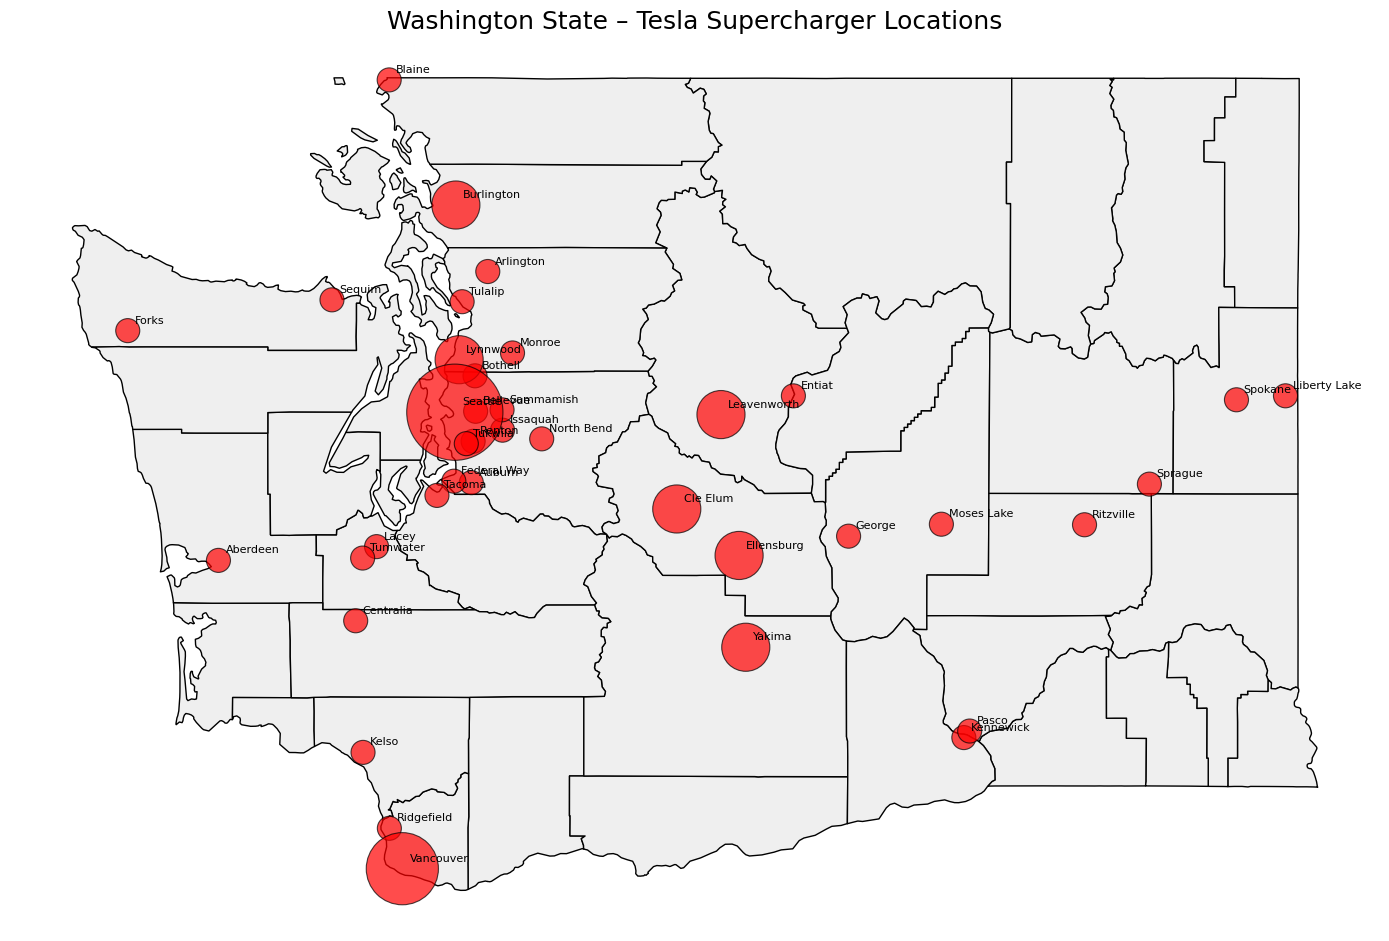

Map saved to: /Users/judycheng/Desktop/WA_supercharger_map.png


In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt

# ======================================================
# LOAD THE SUMMARY EXCEL WITH COORDINATES
# ======================================================
df_map = pd.read_excel(desktop_path)

# Convert to GeoDataFrame
gdf_points = gpd.GeoDataFrame(
    df_map,
    geometry=gpd.points_from_xy(df_map["lon"], df_map["lat"]),
    crs="EPSG:4326"
)

# ======================================================
# LOAD LOCAL WASHINGTON COUNTY SHAPEFILE
# ======================================================
shp_path = os.path.expanduser("~/Desktop/cb_2022_us_county_5m/cb_2022_us_county_5m.shp")
wa_counties = gpd.read_file(shp_path)

# Filter to Washington state only (FIPS 53)
wa_counties = wa_counties[wa_counties["STATEFP"] == "53"]

# Reproject both layers for plotting
wa_counties = wa_counties.to_crs(epsg=3857)
gdf_points = gdf_points.to_crs(epsg=3857)

# ======================================================
# PLOT MAP
# ======================================================
fig, ax = plt.subplots(figsize=(14, 12))

# County polygons
wa_counties.plot(ax=ax, color="#EFEFEF", edgecolor="black", linewidth=1)

# Dot sizes scaled for visibility
sizes = (gdf_points["Supercharger_Count"] ** 2) * 300

# Plot city supercharger dots
gdf_points.plot(
    ax=ax,
    markersize=sizes,
    color="red",
    alpha=0.7,
    edgecolor="black",
    linewidth=0.8
)

# Optional city labels
for _, row in gdf_points.iterrows():
    ax.text(
        row.geometry.x + 5000,
        row.geometry.y + 5000,
        row["City"],
        fontsize=8
    )

plt.title("Washington State – Tesla Supercharger Locations", fontsize=18)
ax.set_axis_off()
plt.tight_layout()

# Save to Desktop
map_path = os.path.expanduser("~/Desktop/WA_supercharger_map.png")
plt.savefig(map_path, dpi=300)
plt.show()

print("Map saved to:", map_path)


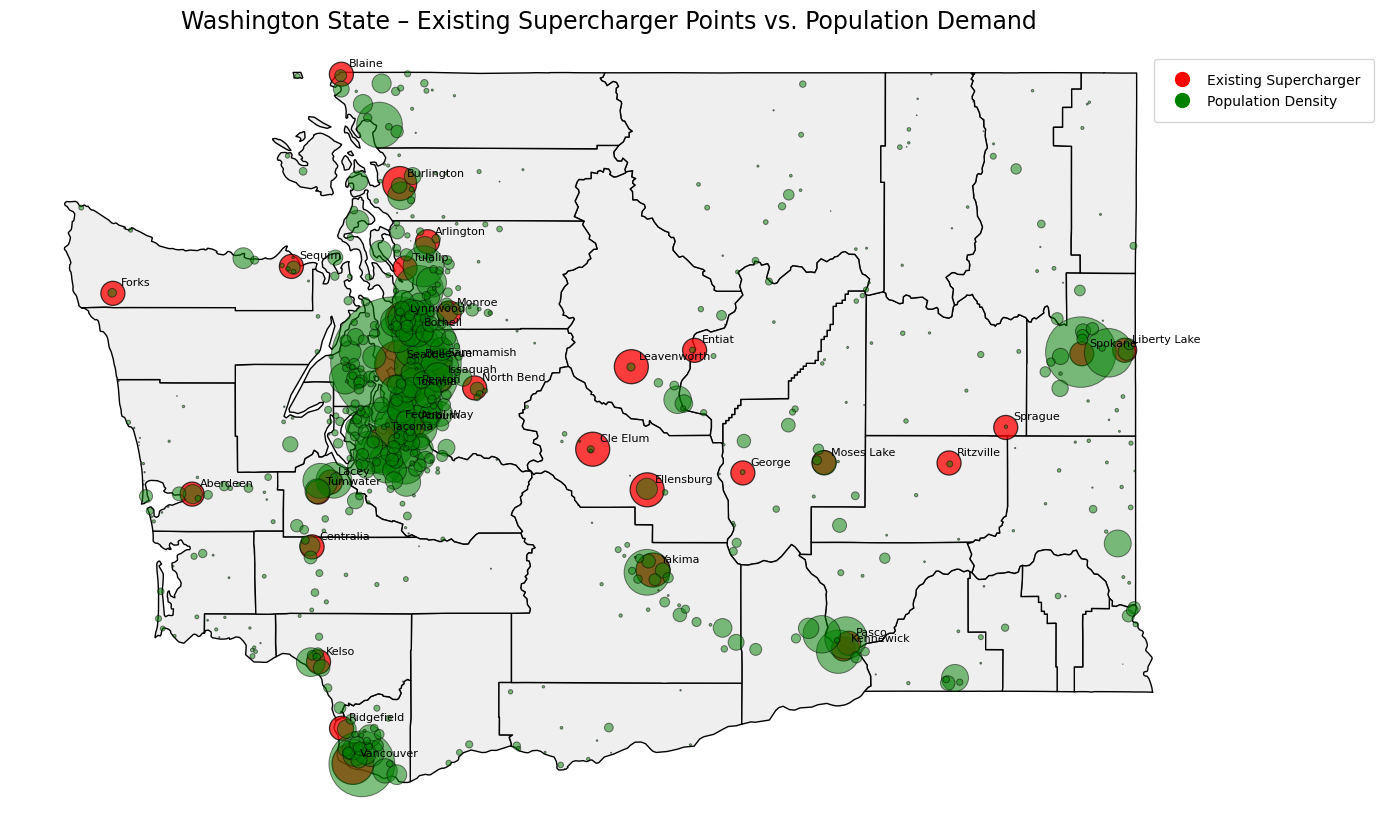

Map saved to: /Users/judycheng/Desktop/WA_supercharger_population_map_large.png


In [19]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import os

# ======================================================
# LOAD SUPERCARGER SUMMARY (EXISTING FILE)
# ======================================================
df_map = pd.read_excel(desktop_path)

# Convert to GeoDataFrame
gdf_points = gpd.GeoDataFrame(
    df_map,
    geometry=gpd.points_from_xy(df_map["lon"], df_map["lat"]),
    crs="EPSG:4326"
)

# ======================================================
# LOAD WASHINGTON COUNTY SHAPEFILE
# ======================================================
shp_path = os.path.expanduser("~/Desktop/cb_2022_us_county_5m/cb_2022_us_county_5m.shp")
wa_counties = gpd.read_file(shp_path)

wa_counties = wa_counties[wa_counties["STATEFP"] == "53"]

# Reproject for plotting
wa_counties = wa_counties.to_crs(epsg=3857)
gdf_points = gdf_points.to_crs(epsg=3857)

# ======================================================
# LOAD POPULATION DATA
# ======================================================
pop_path = os.path.expanduser("~/Desktop/washington-cities-by-population-2025.xlsx")
df_pop = pd.read_excel(pop_path)

gdf_pop = gpd.GeoDataFrame(
    df_pop,
    geometry=gpd.points_from_xy(df_pop["lng"], df_pop["lat"]),
    crs="EPSG:4326"
)

gdf_pop = gdf_pop.to_crs(epsg=3857)

# ======================================================
# DOT SIZE SCALING (LARGE VERSION)
# ======================================================
# 🔴 SUPERCHARGER DOTS — 5× larger than previous
supercharger_sizes = gdf_points["Supercharger_Count"] * 300   # was 60

# 🟢 POPULATION DOTS — 3× larger than previous
population_sizes = gdf_pop["Proportion"] * 75000              # was 25000

# ======================================================
# PLOT MAP
# ======================================================
fig, ax = plt.subplots(figsize=(14, 12))

wa_counties.plot(ax=ax, color="#EFEFEF", edgecolor="black", linewidth=1)

# ------------------------------------------------------
# SUPERCHARGERS (RED, MUCH LARGER)
# ------------------------------------------------------
gdf_points.plot(
    ax=ax,
    markersize=supercharger_sizes,
    color="red",
    alpha=0.75,
    edgecolor="black",
    linewidth=0.9,
    label="Superchargers"
)

# ------------------------------------------------------
# POPULATION DEMAND (GREEN, MUCH LARGER)
# ------------------------------------------------------
gdf_pop.plot(
    ax=ax,
    markersize=population_sizes,
    color="green",
    alpha=0.50,
    edgecolor="black",
    linewidth=0.7,
    label="Population Proportion (%)"
)

# City labels for superchargers
for _, row in gdf_points.iterrows():
    ax.text(
        row.geometry.x + 6000,
        row.geometry.y + 6000,
        row["City"],
        fontsize=8
    )

# ======================================================
# CUSTOM LEGEND (OUTSIDE MAP) — NO TITLE
# ======================================================
import matplotlib.lines as mlines

red_dot = mlines.Line2D([], [], color="red", marker='o', linestyle='None',
                        markersize=10, label="Existing Supercharger")

green_dot = mlines.Line2D([], [], color="green", marker='o', linestyle='None',
                          markersize=10, label="Population Density")

ax.legend(
    handles=[red_dot, green_dot],
    loc="upper left",
    bbox_to_anchor=(.95, .98),
    borderpad=1,
    frameon=True
)



plt.title("Washington State – Existing Supercharger Points vs. Population Demand", fontsize=17)
ax.set_axis_off()
plt.tight_layout()

# Save map
out_path = os.path.expanduser("~/Desktop/WA_supercharger_population_map_large.png")
plt.savefig(out_path, dpi=300)
plt.show()

print("Map saved to:", out_path)


In [20]:
# ======================================================
# CREATE INDIVIDUAL COUNTY MAPS WITH TITLES + LEGEND
# ======================================================
output_folder = os.path.expanduser("~/Desktop/WA_county_maps")
os.makedirs(output_folder, exist_ok=True)

import matplotlib.lines as mlines

for county_name in wa_counties["NAME"].unique():

    # Filter county polygon
    county_geom = wa_counties[wa_counties["NAME"] == county_name]

    # Filter points inside county
    points_in_county = gdf_points[gdf_points.within(county_geom.unary_union)]
    pop_in_county = gdf_pop[gdf_pop.within(county_geom.unary_union)]

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot county boundary
    county_geom.plot(ax=ax, color="#EFEFEF", edgecolor="black", linewidth=1)

    # Plot superchargers
    if len(points_in_county) > 0:
        points_in_county.plot(
            ax=ax,
            markersize=points_in_county["Supercharger_Count"] * 300,
            color="red",
            alpha=0.75,
            edgecolor="black",
            linewidth=0.9,
        )

    # Plot population dots
    if len(pop_in_county) > 0:
        pop_in_county.plot(
            ax=ax,
            markersize=pop_in_county["Proportion"] * 75000,
            color="green",
            alpha=0.50,
            edgecolor="black",
            linewidth=0.7,
        )

    # Title
    ax.set_title(
        f"{county_name} – Existing Supercharger Points vs. Population Demand",
        fontsize=15,
        pad=15
    )

    # ------------------------------------------------------
    # LEGEND (Placed near map, not overlapping county)
    # ------------------------------------------------------
    red_dot = mlines.Line2D([], [], color="red", marker='o', linestyle='None',
                            markersize=10, label="Existing Supercharger")

    green_dot = mlines.Line2D([], [], color="green", marker='o', linestyle='None',
                              markersize=10, label="Population Density")

    ax.legend(
        handles=[red_dot, green_dot],
        loc="upper left",
        bbox_to_anchor=(0.95, 0.90),  # slightly inside, not covering map
        frameon=True,
        borderpad=0.8
    )

    # Remove axes
    ax.set_axis_off()
    plt.tight_layout()

    # Save with clean filename
    file_path = os.path.join(output_folder, f"{county_name}.png")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    plt.close()

print("All county maps saved to:", output_folder)


/var/folders/6f/2tytnt59249dq7mgqy_lsckr0000gn/T/ipykernel_38227/1748153088.py:15: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  points_in_county = gdf_points[gdf_points.within(county_geom.unary_union)]
/var/folders/6f/2tytnt59249dq7mgqy_lsckr0000gn/T/ipykernel_38227/1748153088.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  pop_in_county = gdf_pop[gdf_pop.within(county_geom.unary_union)]
/var/folders/6f/2tytnt59249dq7mgqy_lsckr0000gn/T/ipykernel_38227/1748153088.py:15: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  points_in_county = gdf_points[gdf_points.within(county_geom.unary_union)]
/var/folders/6f/2tytnt59249dq7mgqy_lsckr0000gn/T/ipykernel_38227/1748153088.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  pop_in_county = gdf_pop[gdf_pop.within(coun

All county maps saved to: /Users/judycheng/Desktop/WA_county_maps
